In [1]:
import matplotlib.pyplot as plt
import numpy as np

import src.load_copernics_fieldset as load_copernics_fieldset  # noqa: E402
import src.sargassum_kernels as sargassum_kernels  # noqa: E402

/Users/erik/Codes/Sargassum_growth_model/src/load_copernics_fieldset.py:3: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
fieldset = load_copernics_fieldset.create_fieldset(startdate="2024-07-01T00:00:00", enddate="2024-07-01T00:00:00")

fieldset.mu_max = 0.095  # [doublings/day]
fieldset.mort = 0.025    # [loss/day]
fieldset.T_min = 20.0    # Minimum temperature [degC]
fieldset.T_max = 31.0    # Maximum temperature [degC]
fieldset.T_opt = 27.5    # Optimal temperature [degC]
fieldset.k_N = 0.001     # [mmol/m3]
fieldset.S_opt = 36.0    # [psu]

Loading copernicus_marine_data/copernicusmarine_20240701_20240701_cur.nc
Loading copernicus_marine_data/copernicusmarine_20240701_20240701_so.nc
Loading copernicus_marine_data/copernicusmarine_20240701_20240701_thetao.nc
Loading copernicus_marine_data/copernicusmarine_20240701_20240701_no3.nc
Loading copernicus_marine_data/copernicusmarine_20240701_20240701_stokes.nc
Loading copernicus_marine_data/copernicusmarine_20240701_20240701_wind.nc


In [3]:
N = 100
Trange = np.linspace(14, 38, N)
Tlim = sargassum_kernels.TemperatureGrowthFactor(Trange, fieldset)

k_N_values = [0.000129, 0.001, 0.01]  # mmol/m3
Nrange = np.linspace(0, 0.1, N)
Nlim = {}
for k_N in k_N_values:
    fieldset.k_N = k_N
    Nlim[k_N] = sargassum_kernels.NitrogenGrowthFactor(Nrange, fieldset)

Srange = np.linspace(20, 40, N)
Slim = sargassum_kernels.SalinityGrowthFactor(Srange, fieldset)

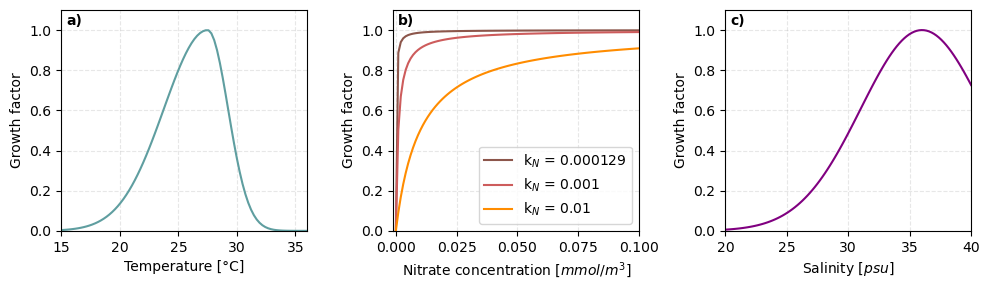

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

#Temperature
ax[0].plot(Trange, Tlim, color='cadetblue')
ax[0].set_xlabel('Temperature [°C]')
ax[0].set_xlim(15,36)

#Nitrogen concentration
colors = {0.000129: 'tab:brown', 0.001: 'indianred', 0.01: 'darkorange'}
for k_N in k_N_values:
    ax[1].plot(Nrange, Nlim[k_N], label=f'k$_N$ = {k_N}', color=colors[k_N])
ax[1].set_xlabel('Nitrate concentration [$mmol / m^3$]')
ax[1].set_xlim(-0.001,0.1)
ax[1].legend(loc='lower right')

#Salinity concentration
ax[2].plot(Srange, Slim, color='purple')
ax[2].set_xlabel('Salinity [$psu$]')
ax[2].set_xlim(20,40)

for i, label in enumerate(['a)', 'b)', 'c)']):
    ax[i].grid(alpha=0.3, linestyle='--')
    ax[i].set_ylabel('Growth factor')
    ax[i].set_ylim([0, 1.1])
    ax[i].text(0.02, 0.98, label, transform=ax[i].transAxes,
               fontsize=10, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig("Figures/FigureA2.pdf", format="pdf", bbox_inches="tight")
plt.show()